# US Firm Characteristics: Backtest and Equal-Weight Baseline

**Chapter 16 - Strategy Simulation**

The US firm characteristics case study is the academic benchmark for
cross-sectional prediction, with roughly 3,700 stocks in the validation
price panel and more than 50 anomaly characteristics. This notebook converts
80 persisted validation prediction sets into 320 long-short, equal-weight
baseline strategies. The leading current-vintage result is
`gbm/leaves_7_mse` at iteration 500 with 50 stocks per side: validation
Sharpe 2.63 [2.07, 3.24]. The sealed holdout is not accessed here.

Three steps:

1. **Plumbing test** - verify random rankings produce no spurious alpha
2. **Parametric sweep** - test all prediction and entry-scheme combinations
3. **Statistical analysis** - compare the completed validation baselines

Sections 1–2 generate new backtest results (write to registry). Section 3
is read-only: it queries the registry via `BacktestExplorer` and can be
re-run independently without re-running the sweep.

**Book Reference:** Chapter 16, Sections 16.4–16.8

**Prerequisites:** Completed model training (Ch11–15) for this case study.

In [1]:
"""Ch16 backtest and equal-weight baseline for US Firm Characteristics."""

import time
import warnings

import polars as pl

from utils.style import COLORS, apply_ml4t_style

warnings.filterwarnings("ignore")
apply_ml4t_style()

from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import build_backtest_spec, serializable_backtest_spec
from case_studies.utils.backtest_runner import (
    normalize_prediction_columns,
    run_backtest,
    run_plumbing_test,
)
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    load_existing_backtest_hashes,
    load_prediction_index,
    read_predictions,
)
from case_studies.utils.sweep_config import get_entry_schemes_for, get_top_n_predictions
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
LABEL = ""
SPLIT = "validation"
TOP_K = 20
MAX_SYMBOLS = 0
FORCE_REBACKTEST = False  # Set True to re-backtest even if a complete backtest_hash exists
TOP_N_PREDICTIONS = None

## 1. Setup & Plumbing Test

Before running the parametric sweep, we verify the backtest pipeline itself
is sound. A random signal applied to the ~2,500-stock universe should produce
Sharpe $\approx 0$. The test keeps the observed validation outcomes fixed,
replaces model scores with seeded random rankings, and sends them through
the same vectorized backtest path as the model predictions.

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "signal")

if not LABEL:
    LABEL = bt_config.primary_label

print(f"""=== Protocol Term Sheet ===
  Case study:    {CASE_STUDY_ID}
  Label:         {LABEL}
  Calendar:      {bt_config.calendar}
  Cadence:       {bt_config.cadence}
  Commission:    {bt_config.commission_bps:.1f} bps
  Slippage:      {bt_config.slippage_bps:.1f} bps
  Total cost:    {bt_config.commission_bps + bt_config.slippage_bps:.1f} bps/leg
  Long/short:    {bt_config.long_short}
""")

=== Protocol Term Sheet ===
  Case study:    us_firm_characteristics
  Label:         fwd_ret_1m
  Calendar:      None
  Cadence:       monthly_month_end
  Commission:    7.5 bps
  Slippage:      5.0 bps
  Total cost:    12.5 bps/leg
  Long/short:    True



In [4]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
n_assets = prices["symbol"].n_unique()
print(f"Prices: {len(prices):,} rows, {n_assets} assets")

pred_index = load_prediction_index(
    CASE_STUDY_ID,
    label=LABEL,
    split=SPLIT,
)
if pred_index.is_empty():
    msg = f"No predictions found for {CASE_STUDY_ID}/{LABEL}/{SPLIT}"
    raise RuntimeError(msg)

plumbing_predictions = normalize_prediction_columns(
    read_predictions(CASE_STUDY_ID, pred_index["prediction_hash"][0])
)

Prices: 252,008 rows, 3708 assets


In [5]:
strategy_spec = build_backtest_spec(
    CASE_STUDY_ID,
    bt_config,
    prices=prices,
    prediction_hash="plumbing_test",
    initial_cash=bt_config.initial_cash,
    chapter="ch16",
    signal={
        "method": "score_weighted_top_k",
        "top_k": TOP_K,
        "long_short": bt_config.long_short,
    },
)

try:
    random_sharpe = run_plumbing_test(
        CASE_STUDY_ID,
        prices,
        strategy_spec,
        predictions=plumbing_predictions,
        label=LABEL,
        top_k=TOP_K,
        initial_cash=bt_config.initial_cash,
        calendar=bt_config.calendar,
    )

    status = "PASS" if abs(random_sharpe) < 1.5 else "FAIL"
    print(f"Random signal Sharpe: {random_sharpe:.3f}  [{status}]")

    if abs(random_sharpe) >= 1.5:
        print("WARNING: Random signal produces non-trivial Sharpe - investigate pipeline")
except ValueError as e:
    if "zero variance" in str(e).lower():
        print(f"Plumbing test skipped: {e} (too few assets for meaningful test)")
        random_sharpe = 0.0
    else:
        raise

Random signal Sharpe: -0.009  [PASS]


## 2. Parametric Sweep

Sweep all prediction and entry-scheme combinations using the **same
`run_backtest()` function** as a single backtest. The sweep is pure
orchestration, not a separate implementation.

The current primary-label index contains four predictive families: linear,
GBM, TabM, and latent factors. Causal DML estimates a treatment effect in a
separate registry table and does not produce trading predictions. This
notebook evaluates only `fwd_ret_1m`; other labels are separate runs rather
than hidden dimensions of this surface.

In [6]:
if TOP_N_PREDICTIONS > 0:
    pred_index = pred_index.head(TOP_N_PREDICTIONS)

n_predictions = len(pred_index)
print(f"Predictions to sweep: {n_predictions}")
ic_min, ic_max = pred_index["ic_mean"].min(), pred_index["ic_mean"].max()
if ic_min is not None:
    print(f"  IC range: {ic_min:.4f} to {ic_max:.4f}")
else:
    print("  IC range: not yet computed")

Predictions to sweep: 80
  IC range: -0.0599 to 0.0832


In [7]:
entry_schemes = get_entry_schemes_for(
    CASE_STUDY_ID, LABEL, n_assets, long_short=bt_config.long_short
)
n_schemes = len(entry_schemes)

print(f"\nEntry schemes ({n_schemes}):")
for es in entry_schemes:
    print(f"  {es['name']}: {es['method']} (top_k={es.get('top_k', '-')})")

total_backtests = n_predictions * n_schemes
print(
    f"\nTotal grid: {n_predictions} predictions x {n_schemes} schemes = {total_backtests} backtests"
)


Entry schemes (4):
  ew_top5: equal_weight_top_k (top_k=5)
  ew_top10: equal_weight_top_k (top_k=10)
  ew_top20: equal_weight_top_k (top_k=20)
  ew_top50: equal_weight_top_k (top_k=50)

Total grid: 80 predictions x 4 schemes = 320 backtests


In [8]:
results = []
t0 = time.time()
failed = 0
skipped = 0
completed_attempts = 0
existing_hashes = load_existing_backtest_hashes(CASE_STUDY_ID, stage="signal")
print(f"Existing equal-weight baseline hashes in registry: {len(existing_hashes):,}")

for pred_row in pred_index.iter_rows(named=True):
    pred_hash = pred_row["prediction_hash"]
    source = pred_row["source"]
    ic_mean = pred_row["ic_mean"]

    pending_schemes = []

    for scheme in entry_schemes:
        signal = {
            "method": scheme["method"],
            "top_k": scheme.get("top_k", 20),
            "long_short": bt_config.long_short,
        }
        signal.update({k: v for k, v in scheme.items() if k not in ("name", "method")})
        spec = build_backtest_spec(
            CASE_STUDY_ID,
            bt_config,
            prices=prices,
            prediction_hash=pred_hash,
            initial_cash=bt_config.initial_cash,
            chapter="ch16",
            signal=signal,
        )
        backtest_hash = backtest_hash_from_parts(pred_hash, serializable_backtest_spec(spec))
        if backtest_hash in existing_hashes:
            skipped += 1
            completed_attempts += 1
            if completed_attempts % 20 == 0 or completed_attempts == total_backtests:
                elapsed = time.time() - t0
                rate = completed_attempts / elapsed if elapsed > 0 else 0
                print(
                    f"  [{completed_attempts}/{total_backtests}] {elapsed:.0f}s "
                    f"({rate:.1f} bt/s) | failed: {failed}"
                )
            continue
        pending_schemes.append((scheme, spec))

    if not pending_schemes:
        continue

    predictions = normalize_prediction_columns(read_predictions(CASE_STUDY_ID, pred_hash))

    for scheme, spec in pending_schemes:
        try:
            result = run_backtest(
                CASE_STUDY_ID,
                pred_hash,
                spec,
                prices=prices,
                predictions=predictions,
                label=LABEL,
                register=True,
                force_rebacktest=FORCE_REBACKTEST,
                initial_cash=bt_config.initial_cash,
                calendar=bt_config.calendar,
            )

            results.append(
                {
                    "prediction_hash": pred_hash,
                    "source": source,
                    "ic_mean": ic_mean,
                    "family": pred_row["family"],
                    "config_name": pred_row["config_name"],
                    "signal_method": scheme["name"],
                    "backtest_hash": result.backtest_hash,
                    "sharpe": result.metrics["sharpe"],
                    "total_return": result.metrics["total_return"],
                    "max_drawdown": result.metrics["max_drawdown"],
                    "cagr": result.metrics.get("cagr", 0.0),
                    "volatility": result.metrics.get("volatility", 0.0),
                    "num_trades": result.metrics.get("num_trades", 0),
                }
            )
            if result.backtest_hash:
                existing_hashes.add(result.backtest_hash)
        except Exception as e:
            failed += 1
            results.append(
                {
                    "prediction_hash": pred_hash,
                    "source": source,
                    "ic_mean": ic_mean,
                    "family": pred_row["family"],
                    "config_name": pred_row["config_name"],
                    "signal_method": scheme["name"],
                    "backtest_hash": None,
                    "sharpe": None,
                    "total_return": None,
                    "max_drawdown": None,
                    "cagr": None,
                    "volatility": None,
                    "num_trades": None,
                }
            )

        completed_attempts += 1
        if completed_attempts % 20 == 0 or completed_attempts == total_backtests:
            elapsed = time.time() - t0
            rate = completed_attempts / elapsed if elapsed > 0 else 0
            print(
                f"  [{completed_attempts}/{total_backtests}] {elapsed:.0f}s "
                f"({rate:.1f} bt/s) | failed: {failed}"
            )

elapsed = time.time() - t0
print(
    f"\nSweep complete: {len(results)} backtests in {elapsed:.0f}s ({failed} failed, {skipped} skipped)"
)

Existing equal-weight baseline hashes in registry: 320
  [20/320] 0s (1236.8 bt/s) | failed: 0
  [40/320] 0s (1350.5 bt/s) | failed: 0


  [60/320] 0s (1374.9 bt/s) | failed: 0
  [80/320] 0s (1403.2 bt/s) | failed: 0
  [100/320] 0s (1424.2 bt/s) | failed: 0
  [120/320] 0s (1440.5 bt/s) | failed: 0
  [140/320] 0s (1444.2 bt/s) | failed: 0
  [160/320] 0s (1449.6 bt/s) | failed: 0
  [180/320] 0s (1457.2 bt/s) | failed: 0
  [200/320] 0s (1461.0 bt/s) | failed: 0
  [220/320] 0s (1464.0 bt/s) | failed: 0
  [240/320] 0s (1468.7 bt/s) | failed: 0
  [260/320] 0s (1469.3 bt/s) | failed: 0


  [280/320] 0s (1466.6 bt/s) | failed: 0


  [300/320] 0s (1464.6 bt/s) | failed: 0
  [320/320] 0s (1464.9 bt/s) | failed: 0

Sweep complete: 0 backtests in 0s (0 failed, 320 skipped)


## 3. Equal-Weight Baseline Evaluation

This section is **read-only**: it queries the registry via `BacktestExplorer`
and does not depend on the sweep having just run. You can re-run this section
at any time to analyze existing results.

Key questions for this case study: Do the primary-label predictions translate
into positive validation Sharpe? Which model families dominate the upper tail?
How tightly does IC map to portfolio performance across the 320 baselines?

In [9]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)
print(repr(explorer))

BacktestExplorer('us_firm_characteristics', 320 runs: signal=320)


### Top Strategies

The current baseline rank-1 is `gbm/leaves_7_mse` at iteration 500 with
50 stocks per side. Its validation Sharpe is 2.63 [2.07, 3.24], ahead of
`gbm/leaves_7_huber` at 2.55. Portfolio construction has not yet entered
this current-vintage lineage.

In [10]:
top = explorer.best(stage="signal", top_n=10)
print(top.select("source", "signal_method", "sharpe", "cagr", "max_drawdown"))

shape: (10, 5)
┌─────────────────────┬────────────────────┬──────────┬──────────┬──────────────┐
│ source              ┆ signal_method      ┆ sharpe   ┆ cagr     ┆ max_drawdown │
│ ---                 ┆ ---                ┆ ---      ┆ ---      ┆ ---          │
│ str                 ┆ str                ┆ f64      ┆ f64      ┆ f64          │
╞═════════════════════╪════════════════════╪══════════╪══════════╪══════════════╡
│ gbm/leaves_7_mse    ┆ equal_weight_top_k ┆ 2.63214  ┆ 0.90156  ┆ -0.108196    │
│ gbm/leaves_7_huber  ┆ equal_weight_top_k ┆ 2.548265 ┆ 0.912546 ┆ -0.132748    │
│ gbm/leaves_15_huber ┆ equal_weight_top_k ┆ 2.491467 ┆ 0.84302  ┆ -0.183429    │
│ gbm/leaves_63_huber ┆ equal_weight_top_k ┆ 2.47469  ┆ 0.863214 ┆ -0.160184    │
│ gbm/leaves_15_mse   ┆ equal_weight_top_k ┆ 2.389393 ┆ 0.831839 ┆ -0.192388    │
│ gbm/leaves_31_huber ┆ equal_weight_top_k ┆ 2.320881 ┆ 0.819155 ┆ -0.220697    │
│ gbm/leaves_7_mse    ┆ equal_weight_top_k ┆ 2.249755 ┆ 2.508623 ┆ -0.427108    │
│

### Model Family Comparison

Which ML model families produce the most robust trading signals?
The best *model* by IC may not produce the best *strategy* by Sharpe.

GBM dominates this primary-label surface: its median validation Sharpe is
1.73 and its maximum is 2.63. TabM follows with median 0.82, latent factors
with 0.66, and linear models with 0.57. This comparison holds the label fixed,
so it isolates family and checkpoint differences from label engineering.

In [11]:
families = explorer.compare_families(stage="signal")
print(families)

shape: (4, 6)
┌────────────────┬─────┬───────────────┬────────────┬────────────┬──────────────┐
│ family         ┆ n   ┆ sharpe_median ┆ sharpe_max ┆ sharpe_q75 ┆ pct_positive │
│ ---            ┆ --- ┆ ---           ┆ ---        ┆ ---        ┆ ---          │
│ str            ┆ u32 ┆ f64           ┆ f64        ┆ f64        ┆ f64          │
╞════════════════╪═════╪═══════════════╪════════════╪════════════╪══════════════╡
│ gbm            ┆ 60  ┆ 1.730098      ┆ 2.63214    ┆ 2.007811   ┆ 100.0        │
│ tabular_dl     ┆ 48  ┆ 0.818216      ┆ 1.922129   ┆ 1.185551   ┆ 100.0        │
│ latent_factors ┆ 100 ┆ 0.661509      ┆ 1.573375   ┆ 0.852887   ┆ 90.0         │
│ linear         ┆ 112 ┆ 0.570449      ┆ 0.848642   ┆ 0.726461   ┆ 98.214286    │
└────────────────┴─────┴───────────────┴────────────┴────────────┴──────────────┘


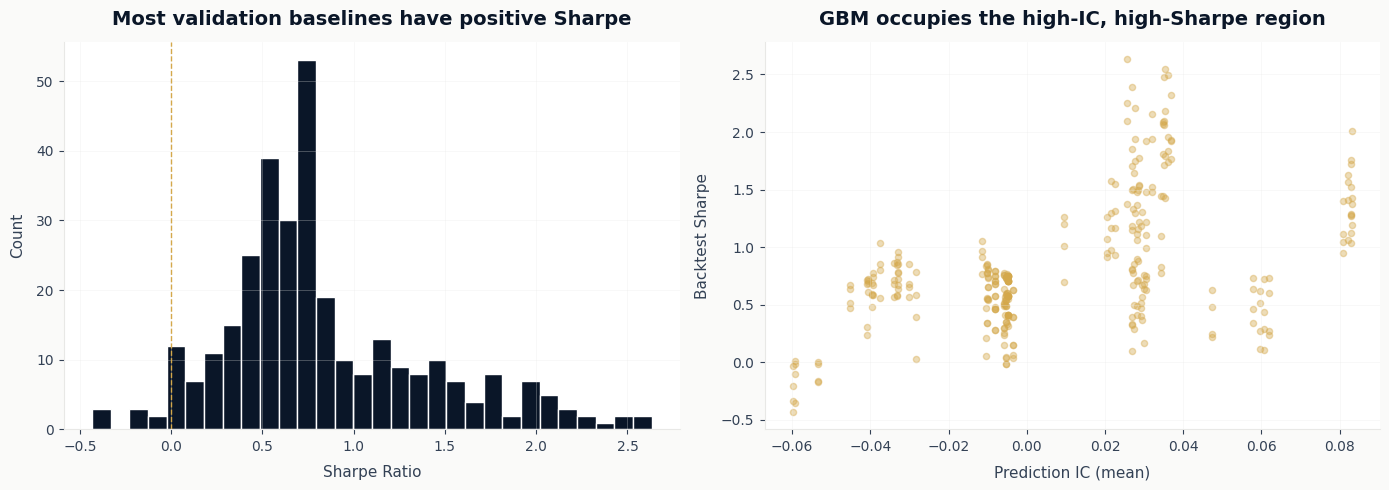

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sharpe distribution histogram
all_signal = explorer.best(stage="signal", top_n=9999)
if not all_signal.is_empty():
    axes[0].hist(all_signal["sharpe"].to_numpy(), bins=30, color=COLORS["blue"], edgecolor="white")
    axes[0].axvline(0, color=COLORS["amber"], linestyle="--", linewidth=1)
    axes[0].set_xlabel("Sharpe Ratio")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Most validation baselines have positive Sharpe")

    # IC vs Sharpe
    axes[1].scatter(
        all_signal["ic_mean"].fill_null(0).to_numpy(),
        all_signal["sharpe"].to_numpy(),
        alpha=0.4,
        s=20,
        color=COLORS["amber"],
    )
    axes[1].set_xlabel("Prediction IC (mean)")
    axes[1].set_ylabel("Backtest Sharpe")
    axes[1].set_title("GBM occupies the high-IC, high-Sharpe region")

fig.tight_layout()
fig.show()

### Deflated Sharpe Ratio

The DSR corrects observed Sharpe ratios for the number of strategies tested.
A strategy that looks good after testing hundreds of configurations may simply
be the best of many noise realizations.

$$DSR = \Phi\left[\frac{(\hat{SR} - SR^*) \sqrt{T-1}}{\sqrt{1 - \hat{\gamma}_3 \hat{SR} + \frac{\hat{\gamma}_4 - 1}{4} \hat{SR}^2}}\right]$$

This first stage reports raw validation Sharpe and its per-strategy uncertainty.
Cohort-level DSR, effective trial counts, and PBO remain null until the complete
current-vintage allocation, cost, and risk lineage exists. The final strategy
analysis computes those selection-adjusted statistics once, after the funnel is
complete; this notebook does not infer them from the frozen vintage.

In [13]:
from case_studies.utils.backtest_loaders import print_stage_dsr_summary

print_stage_dsr_summary(explorer, top_n=20, head=10)


--- DSR @ signal (K=20) ---
shape: (10, 21)
┌───────────────┬────────┬────────────┬────────┬───┬────────────┬────────────┬──────────────┬──────┐
│ source        ┆ family ┆ label      ┆ sharpe ┆ … ┆ ras_leader ┆ ras_pvalue ┆ reality_chec ┆ pbo  │
│ ---           ┆ ---    ┆ ---        ┆ ---    ┆   ┆ ---        ┆ ---        ┆ k_pvalue     ┆ ---  │
│ str           ┆ str    ┆ str        ┆ f64    ┆   ┆ null       ┆ null       ┆ ---          ┆ null │
│               ┆        ┆            ┆        ┆   ┆            ┆            ┆ null         ┆      │
╞═══════════════╪════════╪════════════╪════════╪═══╪════════════╪════════════╪══════════════╪══════╡
│ gbm/leaves_7_ ┆ gbm    ┆ fwd_ret_1m ┆ 2.6321 ┆ … ┆ null       ┆ null       ┆ null         ┆ null │
│ mse           ┆        ┆            ┆        ┆   ┆            ┆            ┆              ┆      │
│ gbm/leaves_7_ ┆ gbm    ┆ fwd_ret_1m ┆ 2.5483 ┆ … ┆ null       ┆ null       ┆ null         ┆ null │
│ huber         ┆        ┆            ┆       

### Sharpe Progression Preview

For the best prediction, show how Sharpe changes across pipeline stages
(if allocation, cost, or risk stages have been run). At this boundary the
progression contains only the equal-weight baseline, which prevents later
stages from being implied before they are executed.

In [14]:
if not top.is_empty():
    best_pred = top["prediction_hash"][0]
    prog = explorer.progression(best_pred)
    if not prog.is_empty():
        print(f"\nSharpe progression for best prediction ({top['source'][0]}):")
        print(prog.select("stage", "sharpe", "cagr", "max_drawdown"))


Sharpe progression for best prediction (gbm/leaves_7_mse):
shape: (1, 4)
┌────────┬─────────┬─────────┬──────────────┐
│ stage  ┆ sharpe  ┆ cagr    ┆ max_drawdown │
│ ---    ┆ ---     ┆ ---     ┆ ---          │
│ str    ┆ f64     ┆ f64     ┆ f64          │
╞════════╪═════════╪═════════╪══════════════╡
│ signal ┆ 2.63214 ┆ 0.90156 ┆ -0.108196    │
└────────┴─────────┴─────────┴──────────────┘


## Key Takeaways

1. Seeded random rankings produce Sharpe near zero through the same vectorized
   path, so the backtest plumbing does not manufacture alpha.
2. Of 320 current-vintage baselines, 308 have positive validation Sharpe.
   That breadth is informative, but the surface is still a selection cohort.
3. `gbm/leaves_7_mse` at iteration 500 and top-50 concentration leads with
   validation Sharpe 2.63 [2.07, 3.24]. GBM also has the strongest family
   median at 1.73.
4. Selection-adjusted DSR and PBO are intentionally deferred until the
   downstream funnel is complete. No frozen-vintage cohort statistic is mixed
   into this current lineage.
5. IC and Sharpe are related but not interchangeable. The scatter shows why
   strategy simulation remains necessary after predictive evaluation.

**Next:** The allocation notebook (Ch17) tests whether portfolio construction
adds material value on top of an already strong signal, and identifies the
optimal concentration level for a 2,500-stock universe.